In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression

RNG = np.random.default_rng(42)

# =============================================================================
# PART 1 — Equation (1): Two multivariate Gaussian mixtures
# -----------------------------------------------------------------------------
# "We generate synthetic loan applications using two multivariate Gaussian
#  mixtures: X_g ~ Σ δ_c N(μ_c^g, Σ_c^g),  X_b ~ Σ δ_c N(μ_c^b, Σ_c^b)
#  where δ_c, μ_c, Σ_c are the weight, mean vector and covariance matrix
#  of the c-th mixture component."
# =============================================================================

C          = 2   # number of mixture components per class
N_FEATURES = 4   # dimensionality of X

# --- X_g: good applicants (low default risk → negative-shifted means) ---
delta_g = [0.6, 0.4]                                  # δ_c weights
mu_g    = [np.array([-1.0, -0.5,  0.3, -0.8]),        # μ_c^g
           np.array([-0.5, -1.0, -0.2,  0.5])]
cov_g   = [np.eye(N_FEATURES) * 0.8,                  # Σ_c^g
           np.eye(N_FEATURES) * 1.0]

# --- X_b: bad applicants (high default risk → positive-shifted means) ---
delta_b = [0.5, 0.5]                                  # δ_c weights
mu_b    = [np.array([ 1.0,  0.8, -0.5,  0.6]),        # μ_c^b
           np.array([ 0.5,  1.2,  0.4, -0.3])]
cov_b   = [np.eye(N_FEATURES) * 0.9,                  # Σ_c^b
           np.eye(N_FEATURES) * 1.1]


def sample_mixture(n, mus, covs, deltas, rng):
    """
    Draws n samples from Σ_c δ_c N(μ_c, Σ_c)  — direct implementation of Eq.(1).
    1. Assign each draw to a component by sampling from Categorical(δ).
    2. Draw from that component's multivariate Gaussian.
    """
    components = rng.choice(len(deltas), size=n, p=deltas)
    return np.vstack([rng.multivariate_normal(mus[c], covs[c]) for c in components])


# =============================================================================
# PART 2 — D_j = {(X, y)} ~ P_XY : batch of i.i.d. applications
# -----------------------------------------------------------------------------
# "Suppose D_j = {(X, y)} is the batch j of i.i.d. applications with
#  (X, y) ~ P_XY where y is unknown at the time of application."
#
# We draw n_bad ~ Binomial(n, p_bad) bad applicants and n_good = n - n_bad
# good applicants, then stack and shuffle them. y is generated here but
# is NOT passed to the scorecard at decision time — it is only revealed
# for accepted applicants after the lending decision.
# =============================================================================

N_BATCH = 200    # batch size n
P_BAD   = 0.20  # prior probability of a bad applicant

def sample_batch(n, p_bad, rng):
    """
    Returns (X, y) ~ P_XY for one batch D_j.
    y is available in the code (ground truth) but is treated as
    unobserved by the scorecard until after the accept/reject decision.
    """
    n_bad  = rng.binomial(n, p_bad)
    n_good = n - n_bad
    X = np.vstack([
        sample_mixture(n_good, mu_g, cov_g, delta_g, rng),   # X_g rows
        sample_mixture(n_bad,  mu_b, cov_b, delta_b, rng),   # X_b rows
    ])
    y = np.hstack([np.zeros(n_good), np.ones(n_bad)])        # 0=good, 1=bad
    idx = rng.permutation(len(y))
    return X[idx], y[idx]


# =============================================================================
# PART 3 — Holdout H drawn once from P_XY
# -----------------------------------------------------------------------------
# "We also draw a holdout sample from P_XY denoted as H. The sample H
#  facilitates assessing scorecard performance and bias correction methods
#  on unseen data representative of the borrower population."
#
# H is drawn before the loop starts and never used for training.
# It represents the true population distribution P_XY — unlike D^a,
# which is biased toward accepts.
# =============================================================================

HOLDOUT_SIZE = 2_000
X_H, y_H = sample_batch(HOLDOUT_SIZE, P_BAD, RNG)


# =============================================================================
# PART 4 — Scorecard f_a(X): predicts P(y=1|X)
# -----------------------------------------------------------------------------
# "We assume a FI approves applications using a scorecard f_a(X) that
#  predicts P(y=1|X)."
#
# Logistic regression serves as f_a. It is initially fitted on a small
# random seed set drawn before the loop (analogous to a bank's legacy model).
# predict_proba(X)[:,1] gives P(y=1|X) for each applicant.
# =============================================================================

X_seed, y_seed = sample_batch(N_BATCH * 5, P_BAD, RNG)
scorecard = LogisticRegression(max_iter=500, random_state=0)
scorecard.fit(X_seed, y_seed)


# =============================================================================
# PART 5 — The acceptance loop: 500 iterations
# -----------------------------------------------------------------------------
# "The FI accepts applicant X if f_a(X) ≤ τ."
# "Acceptance decisions partition D_j into
#     D^a_j = {X_i ∈ X | f_a(X_i) ≤ τ}   (accepts)
#     D^r_j = {X_i ∈ X | f_a(X_i) > τ}   (rejects)"
# "We reveal the labels in D^a_j and retrain the scoring model on
#  D^a = ⋃_{j=1}^{J} D^a_j."
# "We run the acceptance loop for 500 iterations, generating a new batch
#  of applications using the same distribution parameters each time."
# "Over time, D^a grows in size with a bias towards accepts."
# =============================================================================

TAU = 0.40   # approval threshold τ
J   = 500    # total number of batches

D_a_X, D_a_y = [], []   # D^a accumulates accepted (X, y) across all batches

# --- tracked statistics ---
accept_rates = []   # fraction accepted per batch
bias_rates   = []   # fraction of bads in D^a per batch (selection bias)

for j in range(J):

    # --- Draw batch D_j = {(X, y)} ~ P_XY  (y unobserved at decision time) ---
    X_j, y_j = sample_batch(N_BATCH, P_BAD, RNG)

    # --- Score each applicant: f_a(X_i) = P(y=1|X_i) ---
    scores_j = scorecard.predict_proba(X_j)[:, 1]

    # --- Partition D_j into D^a_j (accepted) and D^r_j (rejected) ---
    accepted = scores_j <= TAU   # D^a_j : f_a(X_i) ≤ τ
    rejected = ~accepted         # D^r_j : f_a(X_i) > τ

    # --- Reveal labels only for accepted applicants, accumulate D^a ---
    D_a_X.append(X_j[accepted])
    D_a_y.append(y_j[accepted])   # y_j[rejected] remains unobserved

    # --- Retrain scorecard on D^a = ⋃_{j'≤j} D^a_{j'} ---
    X_train = np.vstack(D_a_X)
    y_train = np.hstack(D_a_y)
    if len(np.unique(y_train)) == 2:        # need both classes to fit
        scorecard.fit(X_train, y_train)

    # --- Track statistics (selection bias visible here) ---
    n_acc      = accepted.sum()
    bad_in_acc = (y_j[accepted] == 1).sum()
    accept_rates.append(n_acc / N_BATCH)
    bias_rates.append(bad_in_acc / max(n_acc, 1))


# =============================================================================
# PART 6 — Sensitivity analysis parameters
# -----------------------------------------------------------------------------
# "The sensitivity analysis comprises a gradual transition from MAR to MNAR.
#  Other factors influencing the effectiveness of BASL include the strength
#  of sampling bias, class imbalance, and the complexity of the classification
#  task. Factors relevant for BE include the validation sample distribution
#  and the class prior for labeling rejects."
#
# These are the knobs to sweep in a sensitivity analysis:
#   - tau        : controls strength of sampling bias (lower τ → stronger bias)
#   - P_BAD      : class imbalance
#   - N_FEATURES : complexity of the classification task
#   - MAR→MNAR   : implemented by making rejection probability depend on y
#                  (MAR = τ only depends on score; MNAR = score correlates with y)
# =============================================================================

sensitivity_grid = {
    "tau":        [0.2, 0.3, 0.4, 0.5, 0.6],   # sampling bias strength
    "p_bad":      [0.05, 0.10, 0.20, 0.35],     # class imbalance
    "mar_to_mnar": np.linspace(0, 1, 6),        # 0=MAR, 1=fully MNAR
}

# Summary
X_all = np.vstack(D_a_X)
y_all = np.hstack(D_a_y)
print("=" * 55)
print(f"  |D^a| after {J} batches : {len(y_all):,}")
print(f"  Accept rate (avg)       : {np.mean(accept_rates):.1%}")
print(f"  Bad rate in D^a (avg)   : {np.mean(bias_rates):.1%}  ← selection bias")
print(f"  True prior P_BAD        : {P_BAD:.1%}")
print(f"  |H|                     : {HOLDOUT_SIZE:,}")
print("=" * 55)

  |D^a| after 500 batches : 80,462
  Accept rate (avg)       : 80.5%
  Bad rate in D^a (avg)   : 5.5%  ← selection bias
  True prior P_BAD        : 20.0%
  |H|                     : 2,000


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/acceptance_loop.png'

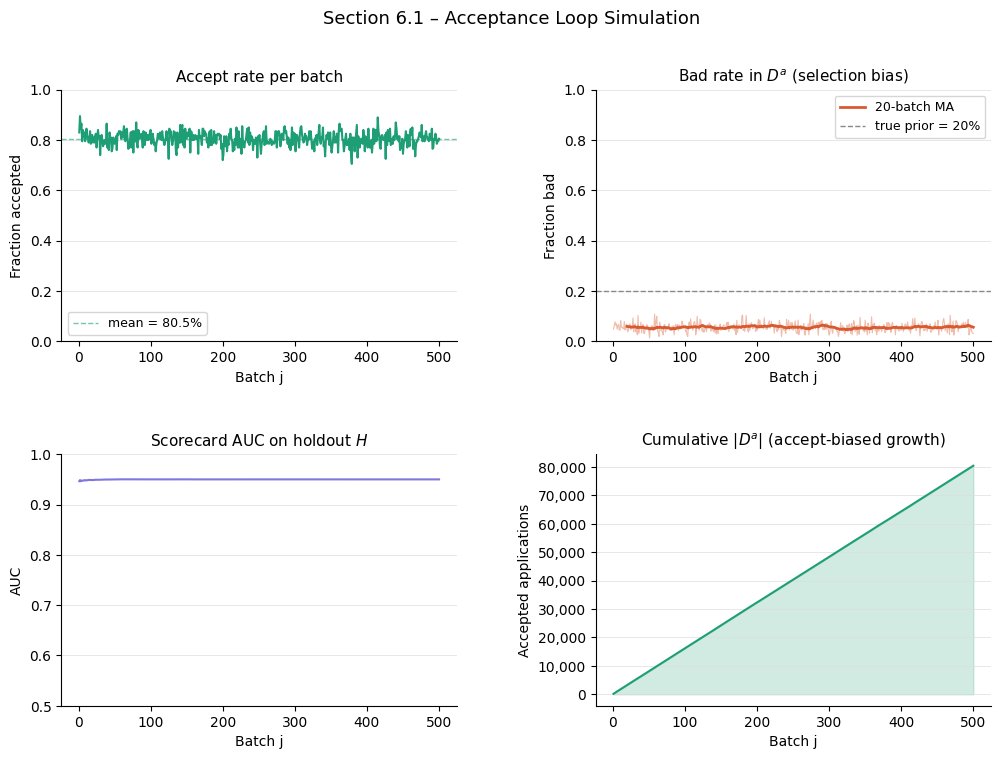

In [3]:

# ── Plots ─────────────────────────────────────────────────────────────────────
iterations = np.arange(1, J + 1)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Section 6.1 – Acceptance Loop Simulation", fontsize=13, y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# --- Panel 1: Accept rate over batches
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(iterations, accept_rates, color="#1D9E75", lw=1.5)
ax1.axhline(np.mean(accept_rates), color="#1D9E75", lw=1, ls="--", alpha=0.6,
            label=f"mean = {np.mean(accept_rates):.1%}")
ax1.set_title("Accept rate per batch", fontsize=11)
ax1.set_xlabel("Batch j")
ax1.set_ylabel("Fraction accepted")
ax1.set_ylim(0, 1)
ax1.legend(fontsize=9)

# --- Panel 2: Bad rate in D^a (selection bias)
ax2 = fig.add_subplot(gs[0, 1])
window = 20
bias_smooth = np.convolve(bias_rates, np.ones(window)/window, mode='valid')
ax2.plot(iterations, bias_rates, color="#D85A30", lw=0.8, alpha=0.4)
ax2.plot(iterations[window-1:], bias_smooth, color="#D85A30", lw=2,
         label=f"{window}-batch MA")
ax2.axhline(P_BAD, color="#888", lw=1, ls="--", label=f"true prior = {P_BAD:.0%}")
ax2.set_title("Bad rate in $D^a$ (selection bias)", fontsize=11)
ax2.set_xlabel("Batch j")
ax2.set_ylabel("Fraction bad")
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)

# --- Panel 3: Holdout AUC
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(iterations, holdout_aucs, color="#7F77DD", lw=1.5)
ax3.set_title("Scorecard AUC on holdout $H$", fontsize=11)
ax3.set_xlabel("Batch j")
ax3.set_ylabel("AUC")
ax3.set_ylim(0.5, 1.0)

# --- Panel 4: Cumulative size of D^a
cumulative_acc = np.cumsum([len(x) for x in D_a_X])
ax4 = fig.add_subplot(gs[1, 1])
ax4.fill_between(iterations, cumulative_acc, color="#1D9E75", alpha=0.2)
ax4.plot(iterations, cumulative_acc, color="#1D9E75", lw=1.5)
ax4.set_title("Cumulative $|D^a|$ (accept-biased growth)", fontsize=11)
ax4.set_xlabel("Batch j")
ax4.set_ylabel("Accepted applications")
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for ax in [ax1, ax2, ax3, ax4]:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#ddd", lw=0.5)

plt.savefig("/mnt/user-data/outputs/acceptance_loop.png", dpi=150, bbox_inches="tight")
plt.close()
print("Plot saved to acceptance_loop.png")